In [1]:
import os
import geopandas as gpd
import numpy as np
import pandas as pd

from src.twl_components import save_to_nc, values_extraction, mean_value_gdf,trim_to_common_period, show_grids_satelite_map
from src.parte_01_T01_EVENTOS_EXTREMOS_single_nc import run as run_extremal_analysis
from src.extremals_post_process import load_extremes_from_mat, slr_extremals, slr_preprocess, plots_extremal_analysis
from src.bathtub_module import bathtub_module
from level_3_risk_analysis.level_3_analysis import main as level_3_risk_analysis
from aed import export_aed_csv
from adaptation import reduce_exp_value,improve_build_res,add_coastal_protection, retreat_buildings
from mapping import pintar_inundacion_edificios, pintar_edificios_por_campo,pintar_diferencia_edificios,pintar_diferencia_rasters,pintar_diferencia_poligonos

TWL COMPONENTS INPUT DATA

In [2]:
got_dir_path = os.path.join(os.getcwd(), 'data', 'TWL', 'got')
got_grid_path = os.path.join(os.getcwd(), 'data', 'TWL', 'got_grid.geojson')

gos_dir_path = os.path.join(os.getcwd(), 'data', 'TWL', 'gos')
gos_grid_path = os.path.join(os.getcwd(), 'data', 'TWL', 'gos_grid.geojson')

gow_dir_path = os.path.join(os.getcwd(), 'data', 'TWL', 'gow')
gow_grid_path = os.path.join(os.getcwd(), 'data', 'TWL', 'gow_grid.geojson')

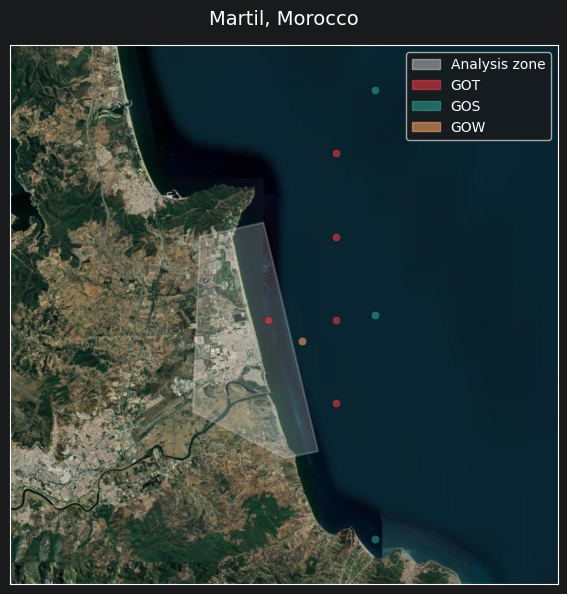

In [4]:
got_grid = gpd.read_file(got_grid_path)
gos_grid = gpd.read_file(gos_grid_path)
gow_grid = gpd.read_file(gow_grid_path)

grids = {
    "GOT": (None, got_grid),
    "GOS": (None, gos_grid),
    "GOW": (None, gow_grid),
}

study_area = gpd.read_file(os.path.join(os.getcwd(), 'data','analysis zone.geojson'))

show_grids_satelite_map(
    grids,
    zoom=12,
    gdf_study_area=study_area,
    titulo="Martil, Morocco"
)


In [3]:
data_got=values_extraction(got_grid_path,got_dir_path,['tide'],got_grid_path)
data_gos=values_extraction(gos_grid_path,gos_dir_path,['zeta'],got_grid_path)
data_gow=values_extraction(gow_grid_path,gow_dir_path,['hs','fp','t02','dir'],got_grid_path)

In [4]:
data_got, data_gos, data_gow = trim_to_common_period(data_got, data_gos, data_gow)

In [5]:
save_to_nc(data_got, data_gos, data_gow,['tide','surge','hs','tp','tm02','dir'])

EXTREME EVENTS DEFINITION

In [8]:
twl_nc_path=os.path.join(os.getcwd(), 'outputs', 'TWL.nc')
outputs_dir=os.path.join(os.getcwd(), 'outputs','extremal_events_analysis')

run_extremal_analysis(
    nc_file=twl_nc_path,
    path_save=outputs_dir,
    mesh="MALLA1",
    subdomain="SUB1",
    j_start=0,
    j_end=None,
    tret=np.array([1, 2, 5, 10, 50, 100, 500 ]),
    make_plots=True,
)

Fichero NetCDF: E:\Proyecto IHRAT\IH Cantabria - Coastal Flooding and Adaptation\outputs\TWL.nc
mesh=MALLA1  subdomain=SUB1


E:\Proyecto IHRAT\IH Cantabria - Coastal Flooding and Adaptation\src\parte_01_T01_EVENTOS_EXTREMOS_single_nc.py:152: UserWarning: Discarding nonzero nanoseconds in conversion.
  ordinal = np.array([d.to_pydatetime().toordinal() for d in dt], dtype=np.float64)


Rango j Python: 0:4  (total=5)
START_TIME total timer launched
POINT_START j_pos=1 total_j=5 j=0 mesh=MALLA1 subdomain=SUB1 lat=35.633335 lon=-5.266671
POINT_STAGE j_pos=1 total_j=5 j=0 mesh=MALLA1 subdomain=SUB1 lat=35.633335 lon=-5.266671 stage=thresholds_start
POINT_STAGE j_pos=1 total_j=5 j=0 mesh=MALLA1 subdomain=SUB1 lat=35.633335 lon=-5.266671 stage=pot_start
POINT_STAGE j_pos=1 total_j=5 j=0 mesh=MALLA1 subdomain=SUB1 lat=35.633335 lon=-5.266671 stage=pot_done n_events=327
POINT_STAGE j_pos=1 total_j=5 j=0 mesh=MALLA1 subdomain=SUB1 lat=35.633335 lon=-5.266671 stage=contorno_start
POINT_STAGE j_pos=1 total_j=5 j=0 mesh=MALLA1 subdomain=SUB1 lat=35.633335 lon=-5.266671 stage=contorno_done
POINT_STAGE j_pos=1 total_j=5 j=0 mesh=MALLA1 subdomain=SUB1 lat=35.633335 lon=-5.266671 stage=modelo_tp_start mpp_count=7
POINT_STAGE j_pos=1 total_j=5 j=0 mesh=MALLA1 subdomain=SUB1 lat=35.633335 lon=-5.266671 stage=modelo_tp_done
POINT_STAGE j_pos=1 total_j=5 j=0 mesh=MALLA1 subdomain=SUB1 l

0

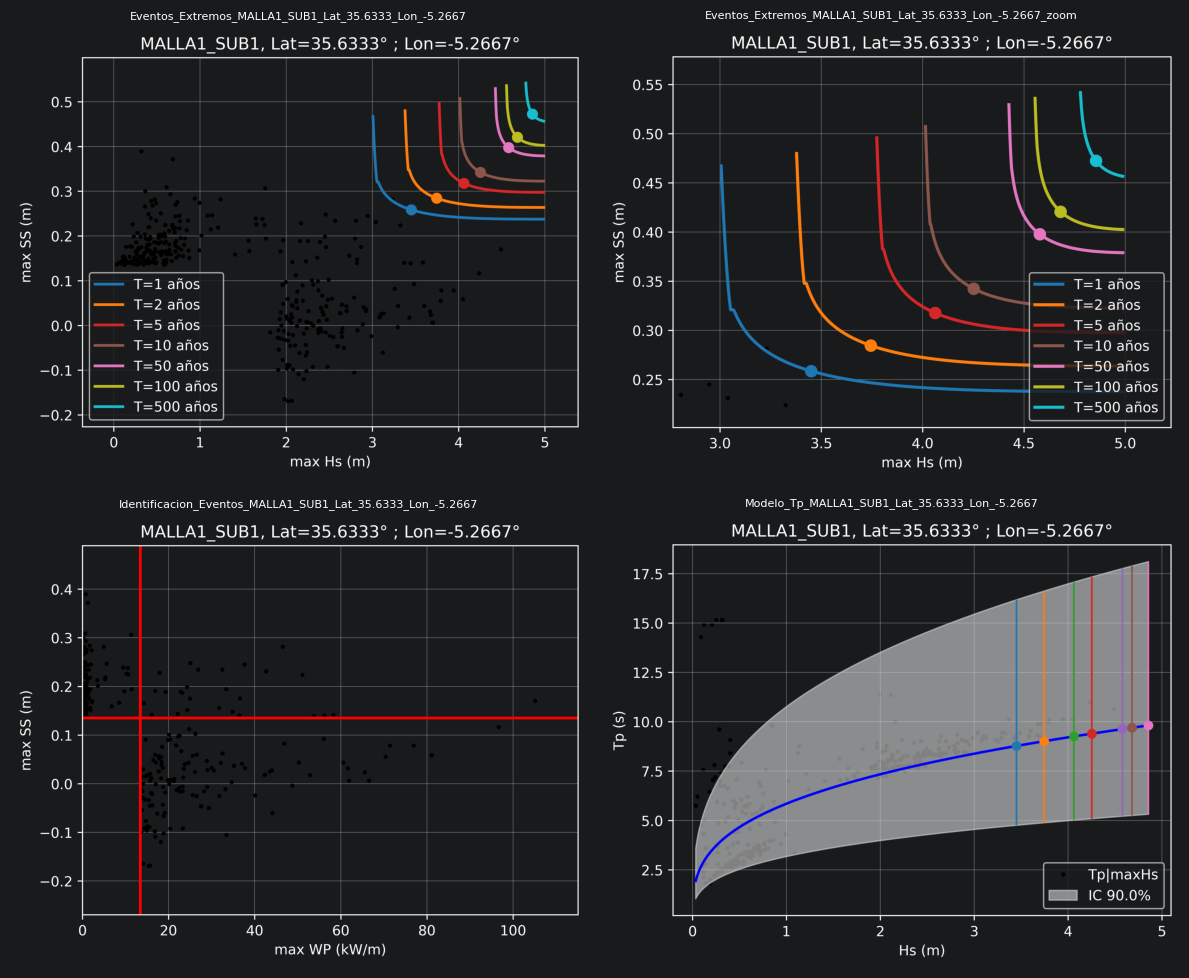

In [9]:
plots_extremal_analysis(mesh='MALLA1', subdomain='SUB1', lat=35.633335, lon=-5.266671)

In [10]:
gdf_extremes = load_extremes_from_mat(
    path_save=os.path.join(os.getcwd(), 'outputs','extremal_events_analysis'),
    mesh="MALLA1",
    subdomain="SUB1",
)

gdf_tide_mean=mean_value_gdf(data_got,crs=4326)

gdf_twl = gdf_extremes.merge(
    gdf_tide_mean[["geometry", "tide"]],
    on="geometry",
    how="left",
)

In [11]:
rp_list=[1, 2, 5, 10, 50, 100, 500]

for rp in rp_list:
    hs_col = f"Hs_{rp}"
    tp_col = f"Tp_{rp}"
    ss_col = f"SS_{rp}"

    L0  = 9.81 * gdf_twl[tp_col] ** 2 / (2 * np.pi)
    swash = 0.046 * np.sqrt(gdf_twl[hs_col] * L0)   # 0.016 + 0.03

    gdf_twl[f"{rp}"] = gdf_twl["tide"] + gdf_twl[ss_col] + swash

out_path = os.path.join(os.getcwd(), 'outputs','twl_extremes.geojson')
gdf_twl.to_file(out_path, driver="GeoJSON")
gdf_twl[["geometry"] + [f"{rp}" for rp in rp_list]]

,geometry,1,2,5,10,50,100,500
0,POINT (-5.23334 35.63333),1.986699,2.134068,2.296560,2.397737,2.583116,2.646721,2.767156
1,POINT (-5.26667 35.63333),1.986699,2.134068,2.296560,2.397737,2.583116,2.646721,2.767156
2,POINT (-5.23334 35.66667),1.985699,2.133068,2.295560,2.396737,2.582116,2.645721,2.766156
3,POINT (-5.23334 35.6),1.986699,2.134068,2.296560,2.397737,2.583116,2.646721,2.767156
4,POINT (-5.23334 35.7),1.988062,2.138946,2.303039,2.407389,2.601479,2.668212,2.796853


ADDING SEA LEVEL RISE PROJECTIONS

In [12]:
gdf_slr=slr_preprocess(
    PERCENTILES = {'05':0.0500000007450581, '50':0.5, '95':0.949999988079071},
    YEARS = {'2050':'Y2050','2080':'Y2080'},
    SSPS = {'ssp245':'245', 'ssp585':'585'},
    slr_points = gpd.read_file(os.path.join(os.getcwd(), 'data', 'TWL', 'slr_grid.geojson')),
    data_dir = os.path.join(os.getcwd(), 'data', 'TWL', 'slr'),
    output_path = os.path.join(os.getcwd(), 'outputs','SLR_grid_values.geojson')
)

SLR_Punto_36.000_-5.000_ssp245.csv
SLR_Punto_36.000_-5.000_ssp585.csv


In [13]:
gdf_twl=slr_extremals(
    gdf_twl=gpd.read_file(os.path.join(os.getcwd(), 'outputs','twl_extremes.geojson')),
    gdf_slr=gpd.read_file(os.path.join(os.getcwd(), 'outputs','SLR_grid_values.geojson')),
    output_path = os.path.join(os.getcwd(), 'outputs','TWL_extremals_projections.geojson'),
    SSPS = ['245', '585'],
    PERCENTILES = ['05', '50', '95'],
    YEARS = ['2050', '2080'],
    RP=['1','2','5','10','50','100','500']
)

rp_list=[1,2, 5, 10, 50, 100, 500]
gdf_twl[["geometry"] + [f'{rp}_{245}_{50}_{2050}' for rp in rp_list]]


,geometry,1_245_50_2050,2_245_50_2050,5_245_50_2050,10_245_50_2050,50_245_50_2050,100_245_50_2050,500_245_50_2050
0,POINT (-5.23334 35.63333),2.165699,2.313068,2.475560,2.576737,2.762116,2.825721,2.946156
1,POINT (-5.26667 35.63333),2.165699,2.313068,2.475560,2.576737,2.762116,2.825721,2.946156
2,POINT (-5.23334 35.66667),2.164699,2.312068,2.474560,2.575737,2.761116,2.824721,2.945156
3,POINT (-5.23334 35.6),2.165699,2.313068,2.475560,2.576737,2.762116,2.825721,2.946156
4,POINT (-5.23334 35.7),2.167062,2.317946,2.482039,2.586389,2.780479,2.847212,2.975853


FLOOD MODELLING (BATHTUB APPROACH)
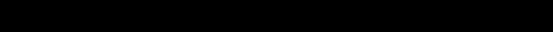

In [7]:
#Run bathtub module with multiple scenarios from a point shapefile
# TWL values will be interpolated using IDW
twl_dic_multi={
    'file_name':'TWL_extremals_projections.geojson',
    'scens_names':[
        '1','2', '5', '10', '50', '100', '500',
         '1_245_05_2050','2_245_05_2050', '5_245_05_2050', '10_245_05_2050', '50_245_05_2050', '100_245_05_2050', '500_245_05_2050',
         '1_245_05_2080','2_245_05_2080', '5_245_05_2080', '10_245_05_2080', '50_245_05_2080', '100_245_05_2080', '500_245_05_2080',
         '1_245_50_2050','2_245_50_2050', '5_245_50_2050', '10_245_50_2050', '50_245_50_2050', '100_245_50_2050', '500_245_50_2050',
         '1_245_50_2080','2_245_50_2080', '5_245_50_2080', '10_245_50_2080', '50_245_50_2080', '100_245_50_2080', '500_245_50_2080',
         '1_245_95_2050','2_245_95_2050', '5_245_95_2050', '10_245_95_2050', '50_245_95_2050', '100_245_95_2050', '500_245_95_2050',
         '1_245_95_2080','2_245_95_2080', '5_245_95_2080', '10_245_95_2080', '50_245_95_2080', '100_245_95_2080', '500_245_95_2080',
         '1_585_05_2050','2_585_05_2050', '5_585_05_2050', '10_585_05_2050', '50_585_05_2050', '100_585_05_2050', '500_585_05_2050',
         '1_585_05_2080','2_585_05_2080', '5_585_05_2080', '10_585_05_2080', '50_585_05_2080', '100_585_05_2080', '500_585_05_2080',
         '1_585_50_2050','2_585_50_2050', '5_585_50_2050', '10_585_50_2050', '50_585_50_2050', '100_585_50_2050', '500_585_50_2050',
         '1_585_50_2080','2_585_50_2080', '5_585_50_2080', '10_585_50_2080', '50_585_50_2080', '100_585_50_2080', '500_585_50_2080',
         '1_585_95_2050','2_585_95_2050', '5_585_95_2050', '10_585_95_2050', '50_585_95_2050', '100_585_95_2050', '500_585_95_2050',
         '1_585_95_2080','2_585_95_2080', '5_585_95_2080', '10_585_95_2080', '50_585_95_2080', '100_585_95_2080', '500_585_95_2080'
    ]
}

coastlines_file_name='coastlines.geojson'
crs=32630
bathtub_module(twl_dic_multi, 'reference_coastline.geojson', crs, input_type='multi value',mdt_filename='MDT_Martil.tif',idw_files=True)

Martil_1
Martil_2
Martil_5
Martil_10
Martil_50
Martil_100
Martil_500
Martil_1_245_05_2050
Martil_2_245_05_2050
Martil_5_245_05_2050
Martil_10_245_05_2050
Martil_50_245_05_2050
Martil_100_245_05_2050
Martil_500_245_05_2050
Martil_1_245_05_2080
Martil_2_245_05_2080
Martil_5_245_05_2080
Martil_10_245_05_2080
Martil_50_245_05_2080
Martil_100_245_05_2080
Martil_500_245_05_2080
Martil_1_245_50_2050
Martil_2_245_50_2050
Martil_5_245_50_2050
Martil_10_245_50_2050
Martil_50_245_50_2050
Martil_100_245_50_2050
Martil_500_245_50_2050
Martil_1_245_50_2080
Martil_2_245_50_2080
Martil_5_245_50_2080
Martil_10_245_50_2080
Martil_50_245_50_2080
Martil_100_245_50_2080
Martil_500_245_50_2080
Martil_1_245_95_2050
Martil_2_245_95_2050
Martil_5_245_95_2050
Martil_10_245_95_2050
Martil_50_245_95_2050
Martil_100_245_95_2050
Martil_500_245_95_2050
Martil_1_245_95_2080
Martil_2_245_95_2080
Martil_5_245_95_2080
Martil_10_245_95_2080
Martil_50_245_95_2080
Martil_100_245_95_2080
Martil_500_245_95_2080
Martil_1_585_

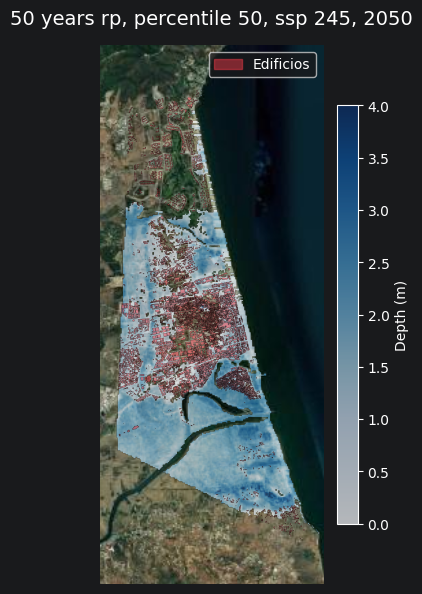

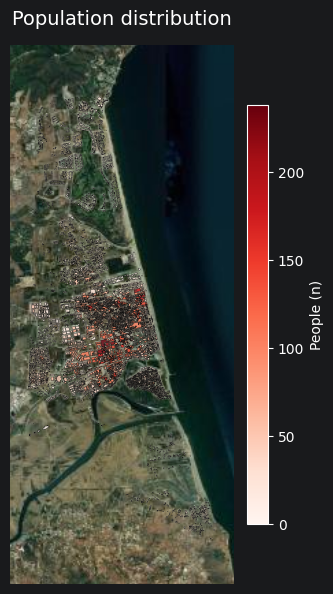

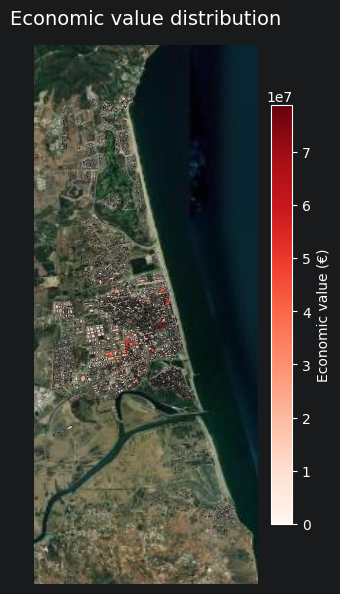

In [16]:
gdf_buildings_pop = gpd.read_file(os.path.join(os.getcwd(), 'data/exposed_system','buildings_Martil_pop.geojson'))
gdf_buildings_uses = gpd.read_file(os.path.join(os.getcwd(), 'data/exposed_system','buildings_Martil_uses.geojson'))
raster_path    = os.path.join(os.getcwd(), 'outputs/flood_maps','flooding_Martil_50_245_50_2050.tif')

pintar_inundacion_edificios(
    gdf_buildings=gdf_buildings_pop,
    raster_path=raster_path,
    buildings_color= "#e63946",
    zoom=12,
    raster_vmin=0,
    raster_vmax=4,        # ajusta al rango de profundidad que esperas
    titulo="50 years rp, percentile 50, ssp 245, 2050",
    scale_label="Depth (m)",
)

pintar_edificios_por_campo(
    gdf_buildings=gdf_buildings_pop,
    value_col="EXP_VALUE",
    zoom=12,
    cmap="Reds",
    scale_label="People (n)",
    titulo="Population distribution",
)

pintar_edificios_por_campo(
    gdf_buildings=gdf_buildings_uses,
    value_col="EXP_VALUE",
    zoom=12,
    cmap="Reds",
    scale_label="Economic value (€)",
    titulo="Economic value distribution",
)

RISK ASSESSMENT

In [2]:
hazard_input_dic = {
    'Flooding': {
        'folder': 'flood_maps',
        'extension': '.tif'
    }
}

params_dic = {
    'scenarios': ['245'],
    'horizons': ['2050'],
    'return periods': ['1', '2','5', '10', '50', '100', '500'],
    'percentiles': ['50'],
    'partial agg': False,
    'zonal stats method': 'centers',
    'zonal stats value': 'mean'
}

# Execute Level 3 Analysis
level_3_risk_analysis(hazard_input_dic, params_dic,'exposed_system')

245_2050_1_50
245_2050_2_50
245_2050_5_50
245_2050_10_50
245_2050_50_50
245_2050_100_50
245_2050_500_50
buildings_Martil_pop
245_2050_1_50
245_2050_2_50
245_2050_5_50
245_2050_10_50
245_2050_50_50
245_2050_100_50
245_2050_500_50
buildings_Martil_uses


In [8]:
os.rename(os.path.join(os.getcwd(), 'outputs/csvs'), os.path.join(os.getcwd(), 'outputs/csvs_basic'))
os.rename(os.path.join(os.getcwd(), 'outputs/shps'), os.path.join(os.getcwd(), 'outputs/shps_basic'))
os.rename(os.path.join(os.getcwd(), 'outputs/flood_maps'), os.path.join(os.getcwd(), 'outputs/flood_maps_basic'))
os.rename(os.path.join(os.getcwd(), 'outputs/idw'), os.path.join(os.getcwd(), 'outputs/idw_basic'))

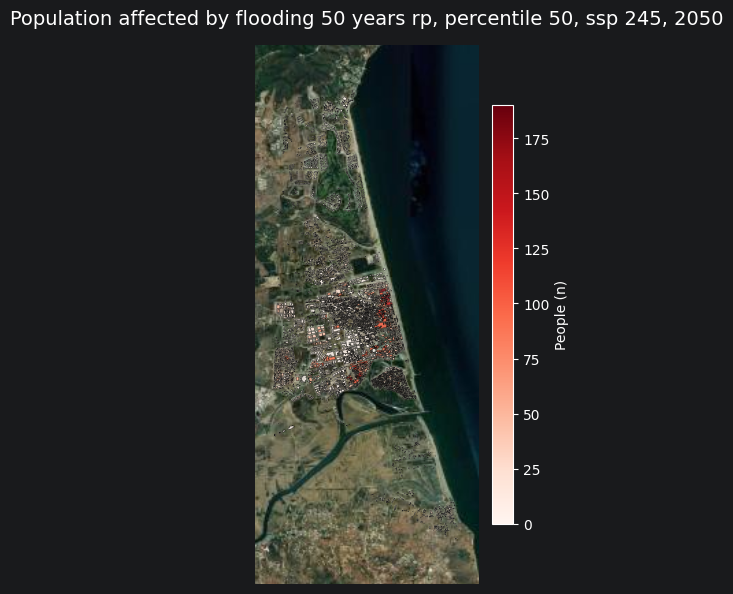

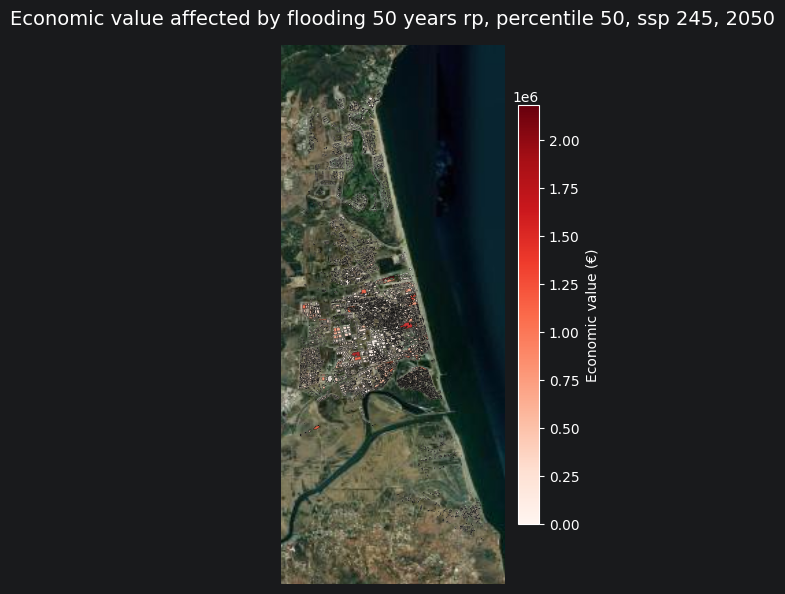

In [4]:
gdf_buildings_pop = gpd.read_file(os.path.join(os.getcwd(), 'outputs/shps_basic','buildings_Martil_pop245_2050_50_50.geojson'))
gdf_buildings_uses = gpd.read_file(os.path.join(os.getcwd(), 'outputs/shps_basic','buildings_Martil_uses245_2050_50_50.geojson'))

pintar_edificios_por_campo(
    gdf_buildings=gdf_buildings_pop,
    value_col="IMP_DAMAGE",
    zoom=12,
    cmap="Reds",
    scale_label="People (n)",
    titulo="Population affected by flooding 50 years rp, percentile 50, ssp 245, 2050",
)

pintar_edificios_por_campo(
    gdf_buildings=gdf_buildings_uses,
    value_col="IMP_DAMAGE",
    zoom=12,
    cmap="Reds",
    scale_label="Economic value (€)",
    titulo="Economic value affected by flooding 50 years rp, percentile 50, ssp 245, 2050",
)

In [5]:
csv_path = os.path.join(os.getcwd(), 'outputs/csvs_basic', 'results_summary.csv')
pd.read_csv(csv_path, sep=';')

,Exposed system,Type of element,Exposed value,Impact scenario,Impact damage
0,buildings_Martil_pop,POP,7.597900e+04,245_2050_1_50,8.422000e+03
1,buildings_Martil_pop,POP,7.597900e+04,245_2050_2_50,1.095800e+04
2,buildings_Martil_pop,POP,7.597900e+04,245_2050_5_50,1.438400e+04
3,buildings_Martil_pop,POP,7.597900e+04,245_2050_10_50,1.647000e+04
4,buildings_Martil_pop,POP,7.597900e+04,245_2050_50_50,2.049700e+04
5,buildings_Martil_pop,POP,7.597900e+04,245_2050_100_50,2.243900e+04
6,buildings_Martil_pop,POP,7.597900e+04,245_2050_500_50,2.484300e+04
7,buildings_Martil_uses,BUILD,7.664462e+09,245_2050_1_50,6.823423e+07
8,buildings_Martil_uses,BUILD,7.664462e+09,245_2050_2_50,8.681436e+07
9,buildings_Martil_uses,BUILD,7.664462e+09,245_2050_5_50,1.120612e+08


In [6]:
csv_path = os.path.join(os.getcwd(), 'outputs/csvs_basic', 'results_summary.csv')
export_aed_csv('aed_results', csv_path)

AED exportado en: E:\Proyecto IHRAT\IH Cantabria - Coastal Flooding and Adaptation\outputs\csvs_basic\aed_results.csv


,Exposed system,Type of element,Exposed value,escen,hor,percentil,AED
0,buildings_Martil_pop,POP,7.597900e+04,245,2050,50,1.207149e+04
1,buildings_Martil_uses,BUILD,7.664462e+09,245,2050,50,9.545829e+07


ADAPTATION MEASURES

1. Accomodation

In [7]:
# 1.A Reduce Exposed Population
geojson_pop_path = os.path.join(os.getcwd(), 'data/exposed_system', 'buildings_Martil_pop.geojson')
output_path = os.path.join(os.getcwd(), 'data/exposed_system_ad1', 'buildings_Martil_pop_reduced.geojson')
reduce_exp_value(geojson_pop_path, output_path)

# 1.B Improve building resistance (reducing vulnerability curve applied)
geojson_uses_path = os.path.join(os.getcwd(), 'data/exposed_system', 'buildings_Martil_uses.geojson')
output_path = os.path.join(os.getcwd(), 'data/exposed_system_ad1', 'buildings_Martil_uses_improved.geojson')
improve_build_res(geojson_uses_path, output_path)

Archivo exportado: E:\Proyecto IHRAT\IH Cantabria - Coastal Flooding and Adaptation\data\exposed_system_ad1\buildings_Martil_pop_reduced.geojson
Archivo exportado: E:\Proyecto IHRAT\IH Cantabria - Coastal Flooding and Adaptation\data\exposed_system_ad1\buildings_Martil_uses_improved.geojson


In [10]:
# Execute Level 3 Analysis
hazard_input_dic = {
    'Flooding': {
        'folder': 'flood_maps_basic',
        'extension': '.tif'
    }
}

params_dic = {
    'scenarios': ['245'],
    'horizons': ['2050'],
    'return periods': ['1','2', '5', '10', '50', '100', '500'],
    'percentiles': ['50'],
    'partial agg': False,
    'zonal stats method': 'centers',
    'zonal stats value': 'mean'
}

level_3_risk_analysis(hazard_input_dic, params_dic,'exposed_system_ad1')

os.rename(os.path.join(os.getcwd(), 'outputs/csvs'), os.path.join(os.getcwd(), 'outputs/csvs_ad1'))
os.rename(os.path.join(os.getcwd(), 'outputs/shps'), os.path.join(os.getcwd(), 'outputs/shps_ad1'))

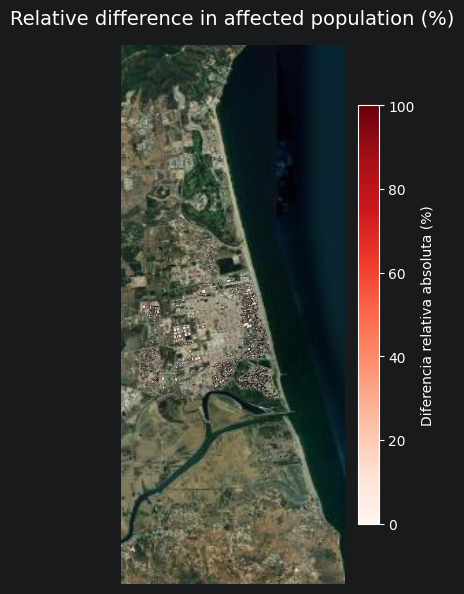

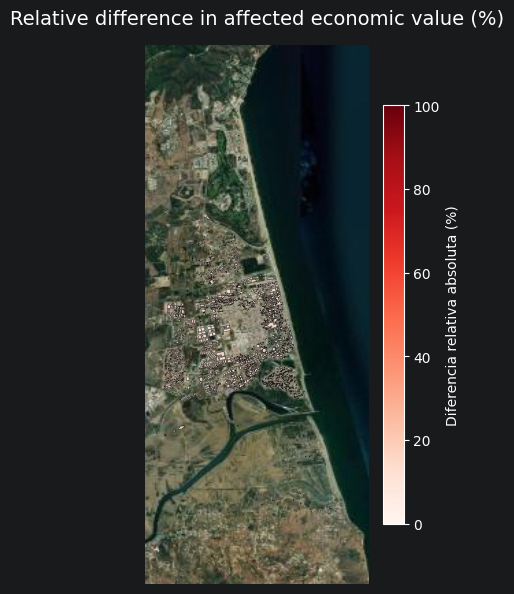

In [11]:
gdf_buildings_pop_basic = gpd.read_file(os.path.join(os.getcwd(), 'outputs/shps_basic','buildings_Martil_pop245_2050_50_50.geojson'))
gdf_buildings_uses_basic = gpd.read_file(os.path.join(os.getcwd(), 'outputs/shps_basic','buildings_Martil_uses245_2050_50_50.geojson'))
gdf_buildings_pop_ad1 = gpd.read_file(os.path.join(os.getcwd(), 'outputs/shps_ad1','buildings_Martil_pop_reduced245_2050_50_50.geojson'))
gdf_buildings_uses_ad1 = gpd.read_file(os.path.join(os.getcwd(), 'outputs/shps_ad1','buildings_Martil_uses_improved245_2050_50_50.geojson'))

pintar_diferencia_edificios(
    gdf_1=gdf_buildings_pop_basic,
    gdf_2=gdf_buildings_pop_ad1,
    value_col="IMP_DAMAGE",
    zoom=12,
    titulo="Relative difference in affected population (%)",
)
pintar_diferencia_edificios(
    gdf_1=gdf_buildings_uses_basic,
    gdf_2=gdf_buildings_uses_ad1,
    value_col="IMP_DAMAGE",
    zoom=12,
    titulo="Relative difference in affected economic value (%)",
)

In [12]:
csv_path = os.path.join(os.getcwd(), 'outputs/csvs_ad1', 'results_summary.csv')
pd.read_csv(csv_path, sep=';')

,Exposed system,Type of element,Exposed value,Impact scenario,Impact damage
0,buildings_Martil_pop_reduced,POP,6.868200e+04,245_2050_1_50,7.584000e+03
1,buildings_Martil_pop_reduced,POP,6.868200e+04,245_2050_2_50,9.868000e+03
2,buildings_Martil_pop_reduced,POP,6.868200e+04,245_2050_5_50,1.295400e+04
3,buildings_Martil_pop_reduced,POP,6.868200e+04,245_2050_10_50,1.483700e+04
4,buildings_Martil_pop_reduced,POP,6.868200e+04,245_2050_50_50,1.845700e+04
5,buildings_Martil_pop_reduced,POP,6.868200e+04,245_2050_100_50,2.020400e+04
6,buildings_Martil_pop_reduced,POP,6.868200e+04,245_2050_500_50,2.237400e+04
7,buildings_Martil_uses_improved,BUILD,7.664462e+09,245_2050_1_50,6.141078e+07
8,buildings_Martil_uses_improved,BUILD,7.664462e+09,245_2050_2_50,7.813289e+07
9,buildings_Martil_uses_improved,BUILD,7.664462e+09,245_2050_5_50,1.008551e+08


In [13]:
csv_path = os.path.join(os.getcwd(), 'outputs/csvs_ad1', 'results_summary.csv')
export_aed_csv('aed_results', csv_path)

AED exportado en: E:\Proyecto IHRAT\IH Cantabria - Coastal Flooding and Adaptation\outputs\csvs_ad1\aed_results.csv


,Exposed system,Type of element,Exposed value,escen,hor,percentil,AED
0,buildings_Martil_pop_reduced,POP,6.868200e+04,245,2050,50,1.087123e+04
1,buildings_Martil_uses_improved,BUILD,7.664462e+09,245,2050,50,8.591243e+07


2. Protection

In [2]:
# Reduce flood depth by adding coastal (reducing 1m TWL in a zone)
geojson_pop_path = os.path.join(os.getcwd(), 'outputs', 'TWL_extremals_projections.geojson')
output_path = os.path.join(os.getcwd(), 'outputs', 'TWL_extremals_projections_reduced.geojson')
add_coastal_protection(geojson_pop_path, output_path)


Archivo exportado: E:\Proyecto IHRAT\IH Cantabria - Coastal Flooding and Adaptation\outputs\TWL_extremals_projections_reduced.geojson


In [3]:
twl_dic_multi={
    'file_name':'TWL_extremals_projections_reduced.geojson',
    'scens_names':[
        '1','2', '5', '10', '50', '100', '500',
         '1_245_05_2050','2_245_05_2050', '5_245_05_2050', '10_245_05_2050', '50_245_05_2050', '100_245_05_2050', '500_245_05_2050',
         '1_245_05_2080','2_245_05_2080', '5_245_05_2080', '10_245_05_2080', '50_245_05_2080', '100_245_05_2080', '500_245_05_2080',
         '1_245_50_2050','2_245_50_2050', '5_245_50_2050', '10_245_50_2050', '50_245_50_2050', '100_245_50_2050', '500_245_50_2050',
         '1_245_50_2080','2_245_50_2080', '5_245_50_2080', '10_245_50_2080', '50_245_50_2080', '100_245_50_2080', '500_245_50_2080',
         '1_245_95_2050','2_245_95_2050', '5_245_95_2050', '10_245_95_2050', '50_245_95_2050', '100_245_95_2050', '500_245_95_2050',
         '1_245_95_2080','2_245_95_2080', '5_245_95_2080', '10_245_95_2080', '50_245_95_2080', '100_245_95_2080', '500_245_95_2080',
         '1_585_05_2050','2_585_05_2050', '5_585_05_2050', '10_585_05_2050', '50_585_05_2050', '100_585_05_2050', '500_585_05_2050',
         '1_585_05_2080','2_585_05_2080', '5_585_05_2080', '10_585_05_2080', '50_585_05_2080', '100_585_05_2080', '500_585_05_2080',
         '1_585_50_2050','2_585_50_2050', '5_585_50_2050', '10_585_50_2050', '50_585_50_2050', '100_585_50_2050', '500_585_50_2050',
         '1_585_50_2080','2_585_50_2080', '5_585_50_2080', '10_585_50_2080', '50_585_50_2080', '100_585_50_2080', '500_585_50_2080',
         '1_585_95_2050','2_585_95_2050', '5_585_95_2050', '10_585_95_2050', '50_585_95_2050', '100_585_95_2050', '500_585_95_2050',
         '1_585_95_2080','2_585_95_2080', '5_585_95_2080', '10_585_95_2080', '50_585_95_2080', '100_585_95_2080', '500_585_95_2080'
    ]
}

coastlines_file_name='coastlines.geojson'
crs=32630
bathtub_module(twl_dic_multi, 'reference_coastline.geojson', crs, input_type='multi value',mdt_filename='MDT_Martil.tif',idw_files=True)

Martil_1
Martil_2
Martil_5
Martil_10
Martil_50
Martil_100
Martil_500
Martil_1_245_05_2050
Martil_2_245_05_2050
Martil_5_245_05_2050
Martil_10_245_05_2050
Martil_50_245_05_2050
Martil_100_245_05_2050
Martil_500_245_05_2050
Martil_1_245_05_2080
Martil_2_245_05_2080
Martil_5_245_05_2080
Martil_10_245_05_2080
Martil_50_245_05_2080
Martil_100_245_05_2080
Martil_500_245_05_2080
Martil_1_245_50_2050
Martil_2_245_50_2050
Martil_5_245_50_2050
Martil_10_245_50_2050
Martil_50_245_50_2050
Martil_100_245_50_2050
Martil_500_245_50_2050
Martil_1_245_50_2080
Martil_2_245_50_2080
Martil_5_245_50_2080
Martil_10_245_50_2080
Martil_50_245_50_2080
Martil_100_245_50_2080
Martil_500_245_50_2080
Martil_1_245_95_2050
Martil_2_245_95_2050
Martil_5_245_95_2050
Martil_10_245_95_2050
Martil_50_245_95_2050
Martil_100_245_95_2050
Martil_500_245_95_2050
Martil_1_245_95_2080
Martil_2_245_95_2080
Martil_5_245_95_2080
Martil_10_245_95_2080
Martil_50_245_95_2080
Martil_100_245_95_2080
Martil_500_245_95_2080
Martil_1_585_

In [4]:
hazard_input_dic = {
    'Flooding': {
        'folder': 'flood_maps',
        'extension': '.tif'
    }
}

params_dic = {
    'scenarios': ['245'],
    'horizons': ['2050'],
    'return periods': ['1','2', '5', '10', '50', '100', '500'],
    'percentiles': ['50'],
    'partial agg': False,
    'zonal stats method': 'centers',
    'zonal stats value': 'mean'
}

# Execute Level 3 Analysis
level_3_risk_analysis(hazard_input_dic, params_dic,'exposed_system')

245_2050_1_50
245_2050_2_50
245_2050_5_50
245_2050_10_50
245_2050_50_50
245_2050_100_50
245_2050_500_50
buildings_Martil_pop
245_2050_1_50
245_2050_2_50
245_2050_5_50
245_2050_10_50
245_2050_50_50
245_2050_100_50
245_2050_500_50
buildings_Martil_uses


In [5]:
os.rename(os.path.join(os.getcwd(), 'outputs/csvs'), os.path.join(os.getcwd(), 'outputs/csvs_ad2'))
os.rename(os.path.join(os.getcwd(), 'outputs/shps'), os.path.join(os.getcwd(), 'outputs/shps_ad2'))
os.rename(os.path.join(os.getcwd(), 'outputs/flood_maps'), os.path.join(os.getcwd(), 'outputs/flood_maps_ad2'))
os.rename(os.path.join(os.getcwd(), 'outputs/idw'), os.path.join(os.getcwd(), 'outputs/idw_ad2'))

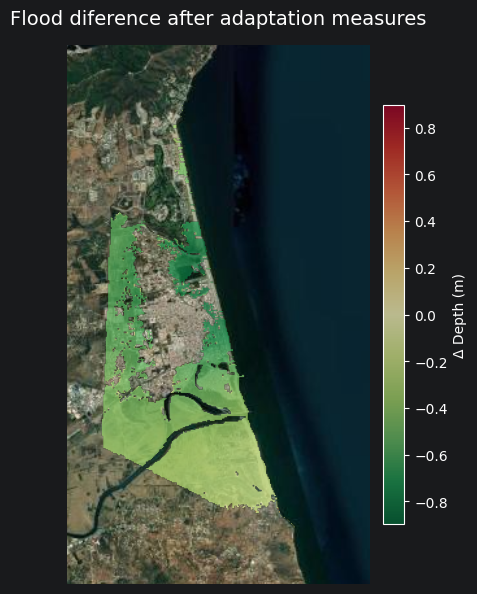

In [6]:
raster_basic_path    = os.path.join(os.getcwd(), 'outputs/flood_maps_basic','flooding_Martil_50_245_50_2050.tif')
raster_ad2_path    = os.path.join(os.getcwd(), 'outputs/flood_maps_ad2','flooding_Martil_50_245_50_2050.tif')

pintar_diferencia_rasters(
    raster_path_1=raster_basic_path,
    raster_path_2=raster_ad2_path,
    zoom=12,
    titulo="Flood diference after adaptation measures",
    scale_label="Δ Depth (m)",
)

In [7]:
csv_path = os.path.join(os.getcwd(), 'outputs/csvs_ad2', 'results_summary.csv')
pd.read_csv(csv_path, sep=';')

,Exposed system,Type of element,Exposed value,Impact scenario,Impact damage
0,buildings_Martil_pop,POP,7.597900e+04,245_2050_1_50,1.274000e+03
1,buildings_Martil_pop,POP,7.597900e+04,245_2050_2_50,2.151000e+03
2,buildings_Martil_pop,POP,7.597900e+04,245_2050_5_50,3.756000e+03
3,buildings_Martil_pop,POP,7.597900e+04,245_2050_10_50,5.220000e+03
4,buildings_Martil_pop,POP,7.597900e+04,245_2050_50_50,8.030000e+03
5,buildings_Martil_pop,POP,7.597900e+04,245_2050_100_50,9.117000e+03
6,buildings_Martil_pop,POP,7.597900e+04,245_2050_500_50,1.097700e+04
7,buildings_Martil_uses,BUILD,7.664462e+09,245_2050_1_50,1.203933e+07
8,buildings_Martil_uses,BUILD,7.664462e+09,245_2050_2_50,1.816063e+07
9,buildings_Martil_uses,BUILD,7.664462e+09,245_2050_5_50,3.818191e+07


In [8]:
csv_path = os.path.join(os.getcwd(), 'outputs/csvs_ad2', 'results_summary.csv')
export_aed_csv('aed_results', csv_path)

AED exportado en: E:\Proyecto IHRAT\IH Cantabria - Coastal Flooding and Adaptation\outputs\csvs_ad2\aed_results.csv


,Exposed system,Type of element,Exposed value,escen,hor,percentil,AED
0,buildings_Martil_pop,POP,7.597900e+04,245,2050,50,2.887211e+03
1,buildings_Martil_uses,BUILD,7.664462e+09,245,2050,50,2.609841e+07


3. Retreat

In [9]:
# Remove development in high-risk areas (flooded under RP50)
tif_path = os.path.join(os.getcwd(), 'outputs/flood_maps_basic', 'flooding_Martil_50_245_50_2050.tif')

geojson_pop_path = os.path.join(os.getcwd(), 'data/exposed_system', 'buildings_Martil_pop.geojson')
output_path = os.path.join(os.getcwd(), 'data/exposed_system_ad3', 'buildings_Martil_pop_retreated.geojson')
retreat_buildings(geojson_pop_path, tif_path, output_path)

geojson_uses_path = os.path.join(os.getcwd(), 'data/exposed_system', 'buildings_Martil_uses.geojson')
output_path = os.path.join(os.getcwd(), 'data/exposed_system_ad3', 'buildings_Martil_uses_retreated.geojson')
improve_build_res(geojson_uses_path, output_path)
retreat_buildings(geojson_uses_path, tif_path, output_path)

Polígonos originales: 6927
Polígonos eliminados: 4449
Polígonos conservados: 2478
Archivo exportado: E:\Proyecto IHRAT\IH Cantabria - Coastal Flooding and Adaptation\data\exposed_system_ad3\buildings_Martil_pop_retreated.geojson
Archivo exportado: E:\Proyecto IHRAT\IH Cantabria - Coastal Flooding and Adaptation\data\exposed_system_ad3\buildings_Martil_uses_retreated.geojson
Polígonos originales: 6927
Polígonos eliminados: 4449
Polígonos conservados: 2478
Archivo exportado: E:\Proyecto IHRAT\IH Cantabria - Coastal Flooding and Adaptation\data\exposed_system_ad3\buildings_Martil_uses_retreated.geojson


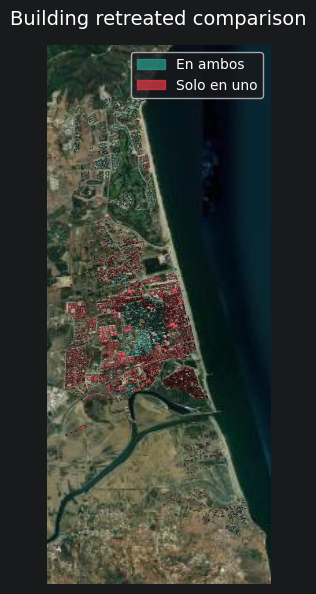

In [10]:
geojson_pop_basic_path = os.path.join(os.getcwd(), 'data/exposed_system', 'buildings_Martil_pop.geojson')
geojson_pop_ad3_path = os.path.join(os.getcwd(), 'data/exposed_system_ad3', 'buildings_Martil_pop_retreated.geojson')

pintar_diferencia_poligonos(
    gdf_1=gpd.read_file(geojson_pop_basic_path),
    gdf_2=gpd.read_file(geojson_pop_ad3_path),
    zoom=12,
    titulo="Building retreated comparison",
)

In [11]:
hazard_input_dic = {
    'Flooding': {
        'folder': 'flood_maps_basic',
        'extension': '.tif'
    }
}

params_dic = {
    'scenarios': ['245'],
    'horizons': ['2050'],
    'return periods': ['1', '5', '10', '50', '100', '500'],
    'percentiles': ['50'],
    'partial agg': False,
    'zonal stats method': 'centers',
    'zonal stats value': 'mean'
}

# Execute Level 3 Analysis
level_3_risk_analysis(hazard_input_dic, params_dic,'exposed_system_ad3')

245_2050_1_50
245_2050_5_50
245_2050_10_50
245_2050_50_50
245_2050_100_50
245_2050_500_50
buildings_Martil_pop_retreated
245_2050_1_50
245_2050_5_50
245_2050_10_50
245_2050_50_50
245_2050_100_50
245_2050_500_50
buildings_Martil_uses_retreated


In [12]:
os.rename(os.path.join(os.getcwd(), 'outputs/csvs'), os.path.join(os.getcwd(), 'outputs/csvs_ad3'))
os.rename(os.path.join(os.getcwd(), 'outputs/shps'), os.path.join(os.getcwd(), 'outputs/shps_ad3'))

In [13]:
csv_path = os.path.join(os.getcwd(), 'outputs/csvs_ad3', 'results_summary.csv')
pd.read_csv(csv_path, sep=';')

,Exposed system,Type of element,Exposed value,Impact scenario,Impact damage
0,buildings_Martil_pop_retreated,POP,2.319300e+04,245_2050_1_50,0.000000e+00
1,buildings_Martil_pop_retreated,POP,2.319300e+04,245_2050_5_50,0.000000e+00
2,buildings_Martil_pop_retreated,POP,2.319300e+04,245_2050_10_50,0.000000e+00
3,buildings_Martil_pop_retreated,POP,2.319300e+04,245_2050_50_50,0.000000e+00
4,buildings_Martil_pop_retreated,POP,2.319300e+04,245_2050_100_50,1.770000e+02
5,buildings_Martil_pop_retreated,POP,2.319300e+04,245_2050_500_50,1.530000e+02
6,buildings_Martil_uses_retreated,BUILD,2.059307e+09,245_2050_1_50,0.000000e+00
7,buildings_Martil_uses_retreated,BUILD,2.059307e+09,245_2050_5_50,0.000000e+00
8,buildings_Martil_uses_retreated,BUILD,2.059307e+09,245_2050_10_50,0.000000e+00
9,buildings_Martil_uses_retreated,BUILD,2.059307e+09,245_2050_50_50,0.000000e+00


In [14]:
csv_path = os.path.join(os.getcwd(), 'outputs/csvs_ad3', 'results_summary.csv')
export_aed_csv('aed_results', csv_path)

AED exportado en: E:\Proyecto IHRAT\IH Cantabria - Coastal Flooding and Adaptation\outputs\csvs_ad3\aed_results.csv


,Exposed system,Type of element,Exposed value,escen,hor,percentil,AED
0,buildings_Martil_pop_retreated,POP,2.319300e+04,245,2050,50,2.205000
1,buildings_Martil_uses_retreated,BUILD,2.059307e+09,245,2050,50,13030.681524
